<a href="https://colab.research.google.com/github/Jefrina-V/VAC-Artificial-Intelligence-and-Data-Science-/blob/main/Day5_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
def display(img,cmap='gray'):
  fig = plt.figure(figsize=(12,10))
  ax = fig.add_subplot(111)
  ax.imshow(img,cmap='gray')

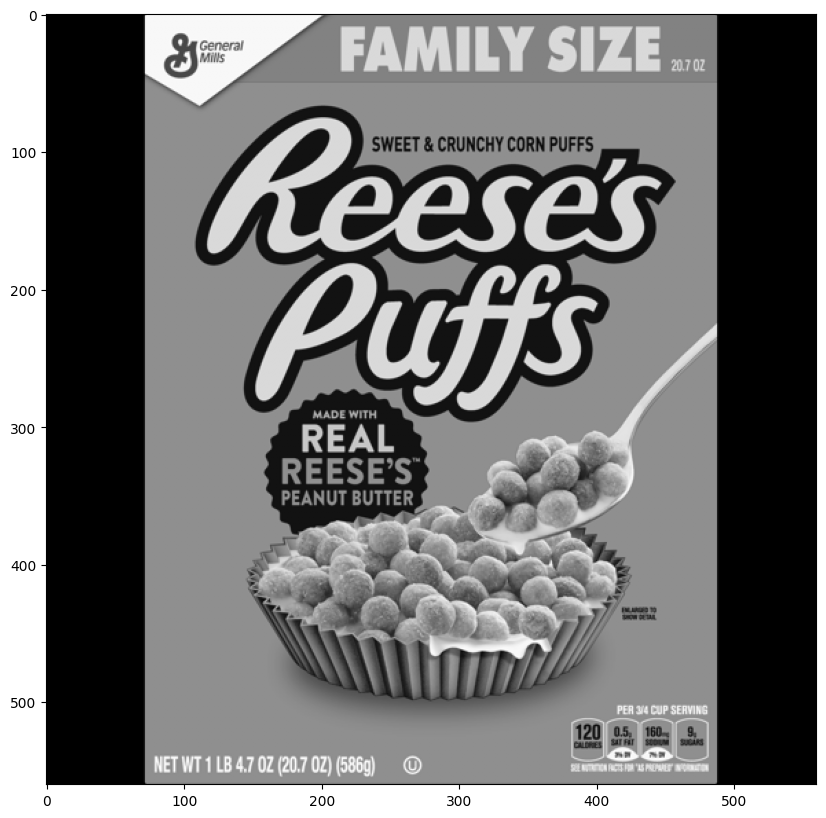

In [ ]:
reeses = cv2.imread('reeses_puffs.png',0)
display(reeses)

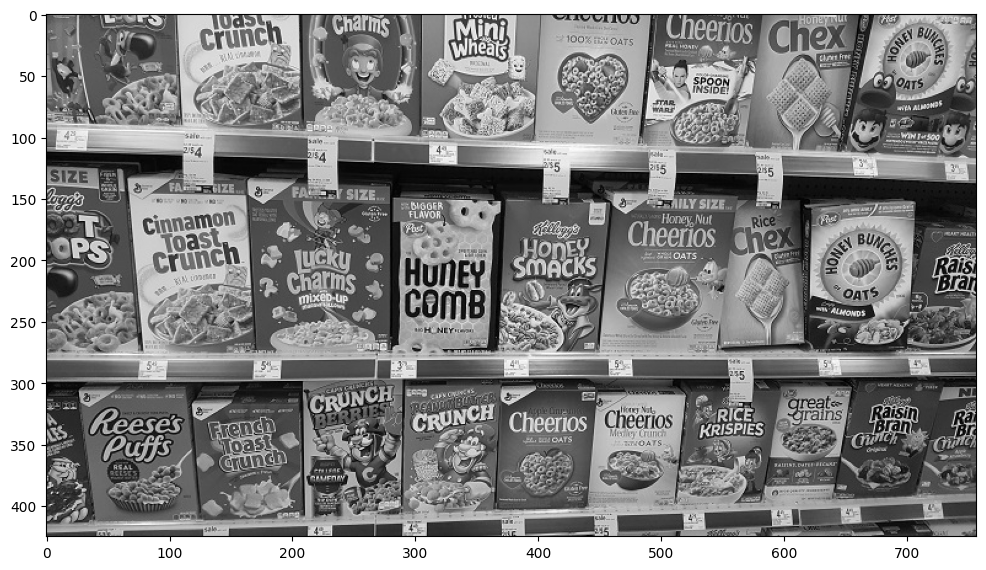

In [ ]:
cearels=cv2.imread('many_cereals.jpg',0)
display(cearels)

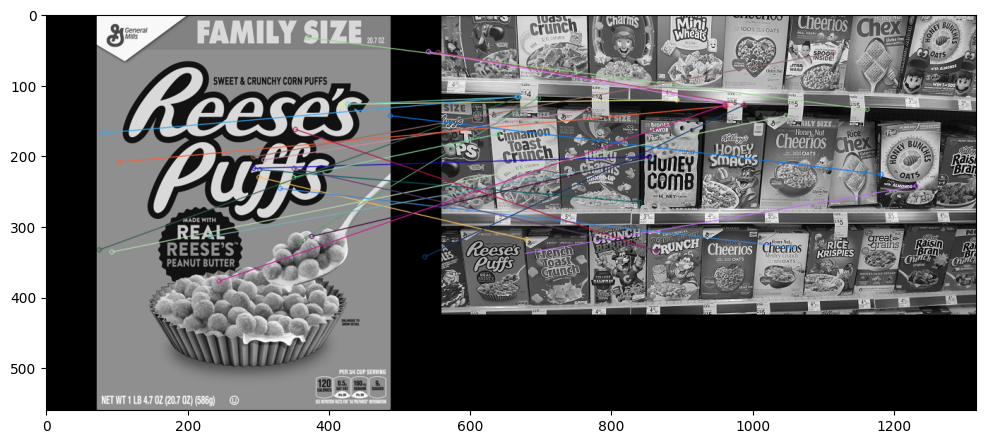

In [ ]:
orb = cv2.ORB_create()
kpl,des1 = orb.detectAndCompute(reeses,None)
kpl,des2 = orb.detectAndCompute(cearels,None)
bf = cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=True)
matches=bf.match(des1,des2)
matches=sorted(matches,key=lambda x:x.distance)
reeses_matches=cv2.drawMatches(reeses,kpl,cearels,kpl,matches[:25],None,flags=2)
display(reeses_matches)

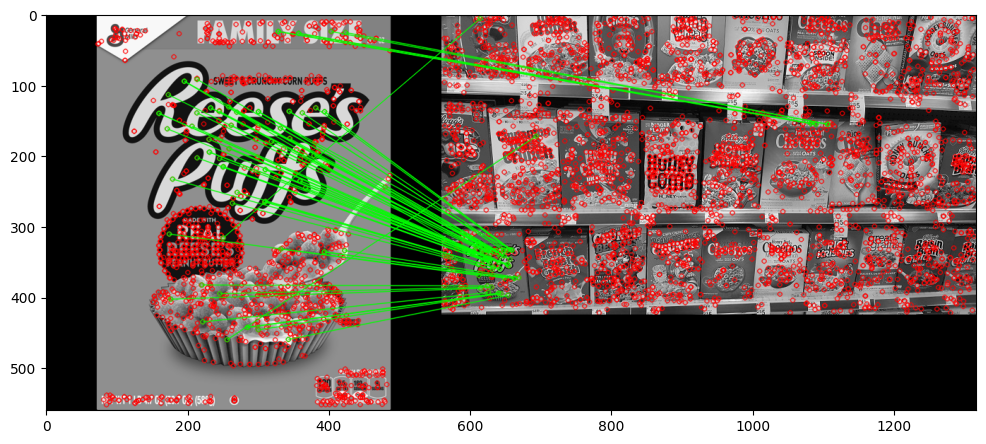

In [ ]:
from re import search
sift = cv2.xfeatures2d.SIFT_create()
kp1,des1 = sift.detectAndCompute(reeses,None)
kp2,des2 = sift.detectAndCompute(cearels,None)
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees =5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params,search_params)
matches = flann.knnMatch(des1,des2,k=2)
matchesMask =[[0,0] for i in range(len(matches))]
for i,(match1,match2) in enumerate(matches):
  if match1.distance <0.7*match2.distance:
    matchesMask[i]=[1,0]

draw_params= dict(matchColor=(0,255,0),
                  singlePointColor=(255,0,0),
                  matchesMask = matchesMask,
                  flags=0)
flann_matches = cv2.drawMatchesKnn(reeses,kp1,cearels,kp2,matches,None,**draw_params)
display(flann_matches)